In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(16)') 

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [3]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles
        using CSV
        using DataFrames 
            
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
        
        df_Sigma_coeffs = CSV.read("NP Sigma grid error/Sigma_coeffs_grid.csv", DataFrame) 
    end
""")

Main.include("core\\setting.jl")
Main.include("core\\constants.jl")
Main.include("core\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\FO.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("Σb.jl")
Main.include("cross section.jl")
Main.include("parallel/fit.jl")

Main.include("initialization.jl")

In [10]:
zmax=0.5
np.arccos(1-2*zmax)*180/np.pi

np.float64(90.0)

In [11]:
χ_fitted_lower = 0.0
χ_fitted_upper = 90
χ_plot_lower = 0.1
χ_plot_upper = 90

In [ ]:
optimal_params = [0.118, 0.84382, 2.55295, 1.08981, 1.25458] #[0.118,0.858,2.31,1.059,1.238]

In [13]:
cut_list = {}
cut_list["sqrtz"] = [0,1/2]

In [15]:
error_type = "both"

df_NNLO = pd.read_csv("fixed order/EECNNLO.csv",header=None)

def fixed_error_func(angle: float, df: pd.DataFrame) -> float:
    angles = df.iloc[:, 0]      
    errors = df.iloc[:, 2]       
    
    pos = np.abs(angles.values - angle).argmin()
    return float(errors.iloc[pos])

In [17]:
#-------------------------------------------------------------------
dataset_names = ["OPAL_new","SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARK II","MAC"]
#-------------------------------------------------------------------

df_original = {}

for name in dataset_names:
    file_path = f"data/{name}.csv"
    df0 = pd.read_csv(file_path)
    
    χ = df0["CHI"]
    EEC = df0["EEC"]
    ERROR = df0["ERROR"]
    Q = df0["Q"]
    BinSize = df0["BinSize"]

    print(Q[0])

    if error_type == "both":
        
        Main.αs_Z = 0.118        
        αs = Main.alpha_s_func(Q[0])
        a = αs/(2*np.pi)

        fixed_error=[]
        for angle in χ:
            value = (a**3)*fixed_error_func(angle=angle, df=df_NNLO)
            fixed_error.append(value)
        ERROR = np.sqrt(df0["ERROR"]**2 + np.array(fixed_error)**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "Q": Q, "BinSize": BinSize})
    df_original[name] = df1

91.2
91.2
59.5
53.3
43.5
34.8
29.0
29.0


In [18]:
cut_list = {}
cut_list["sqrtz"] = [0,np.sqrt(1/2)]

In [19]:
df_truncated = {}

χ = {}
EEC = {}
ERROR = {}
Q = {}
BinSize = {}

df = df_original
for name in dataset_names:
    sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
    kt_list = sqrtz_list*df[name]["Q"]

    if "sqrtz" in cut_list:
        sqrtz_lower, sqrtz_upper = cut_list["sqrtz"]
        df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

    if "kt" in cut_list:
        χ_lower, χ_upper = cut_list["kt"]
        df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

    if "χ" in cut_list:
        kt_lower, kt_upper = cut_list["kt"]
        df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    Q[name] = np.array(df_truncated[name]["Q"])
    BinSize[name] = np.array(df_truncated[name]["BinSize"])

#display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

89

24

24

24

24

24

24

24

In [20]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

In [21]:
def objective(params, df):

    #----------
    XLL = 2 #1 for NLL
    #----------

    N = 5
    
    chi2 = 0
    N_total = 0
    
    αs = params[0]
    params_noαs = params[1:]

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = 1.0')
    Main.eval(f'@everywhere μH_ratio = 1.0')
    Main.eval(f'@everywhere μren_ratio = 1.0') 

    dataset_names = df.keys()

    for name in dataset_names:
        xlist={}
        xlist_mid = np.array(df[name]["CHI"])
        binsize = np.array(df[name]["BinSize"]) 
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        data_size = len(xlist_mid)
        N_total = N_total + data_size

        PRED={}

        parameters = params_noαs
        for quartile in range(N):
            PRED[quartile] = Main.model(xlist=xlist[quartile], Qlist=np.array(df[name]["Q"]))                
        DELTA =  DELTA_func(ylist,PRED)                       

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/N_total

In [22]:
Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL_new"]  = 91.2
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARK II"]    = 29.0
Q_list["MAC"]       = 29.0

Test

In [23]:
objective(optimal_params, df_truncated)

np.float64(1.376624696277857)

Import replicas 

In [24]:
result_set = {}
accuracies = ["fit","scan"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("result/"+XLL+".csv")

In [25]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("      ", ",")
    corrected_string = corrected_string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set = {}
Ω1_set = {}
a_set = {}

for XLL in accuracies:
    df = result_set[XLL]
    αs_set[XLL] = df['αs'].to_numpy()
    arr = np.array(df['params'].map(convert_to_list).tolist(), dtype=float)
    a_set[XLL] = {i: arr[:, i] for i in range(arr.shape[1])}

In [26]:
params_replicas = {}
for XLL in accuracies:
    N_params   = len(a_set[XLL])
    N_replicas = len(a_set[XLL][0])

    params_reps = []
    for i in range(N_replicas):
        params = [float(a_set[XLL][j][i]) for j in range(N_params)]  # <-- cast here
        params_reps.append(params)

    params_replicas[XLL] = params_reps

In [27]:
display(params_replicas)
#display(αs_set)

{'fit': [[0.85554, 2.32609, 1.05853, 1.23548],
  [0.85828, 2.30787, 1.06471, 1.24612],
  [0.86325, 2.29085, 1.06356, 1.23524],
  [0.85461, 2.33663, 1.06271, 1.24275],
  [0.85693, 2.30694, 1.0587, 1.23642],
  [0.85694, 2.27828, 1.0568, 1.24699],
  [0.86299, 2.30526, 1.05368, 1.23391],
  [0.85823, 2.31116, 1.05314, 1.24284],
  [0.8574, 2.32287, 1.05632, 1.23803],
  [0.85679, 2.30697, 1.05029, 1.23192],
  [0.85769, 2.33615, 1.05645, 1.22298],
  [0.85364, 2.32334, 1.05879, 1.23699],
  [0.86111, 2.31555, 1.06125, 1.22813],
  [0.86032, 2.31932, 1.05935, 1.23196],
  [0.85844, 2.30976, 1.06237, 1.24735],
  [0.85822, 2.30791, 1.06325, 1.2353],
  [0.85734, 2.31582, 1.05698, 1.23906],
  [0.85849, 2.30851, 1.06007, 1.22632],
  [0.85697, 2.30817, 1.05667, 1.22956],
  [0.85718, 2.34347, 1.06606, 1.24247],
  [0.85877, 2.3085, 1.05816, 1.23808],
  [0.85797, 2.31467, 1.06258, 1.24953],
  [0.85906, 2.30163, 1.06366, 1.2478],
  [0.85467, 2.31683, 1.05657, 1.24951],
  [0.85576, 2.31718, 1.05563, 1.22833],

In [28]:
N_points=200
xlist = np.linspace(χ_plot_lower, χ_plot_upper, N_points, endpoint=True)
length=len(xlist)
EEC_replicas = {}

Calculate bands

In [29]:
for XLL in accuracies:
    i=0
    EEC_reps = []
    for params in tqdm(params_replicas[XLL]):
        #print(params) 
        EEC = {}
        for name in dataset_names:

            Main.eval(f'@everywhere αs_Z = {αs_set[XLL][i]}')
            Main.eval(f'@everywhere params = {params}') 
            Main.eval(f'@everywhere μJ_ratio = 1.0')
            Main.eval(f'@everywhere μH_ratio = 1.0')
            Main.eval(f'@everywhere μren_ratio = 1.0')              

            Qlist = Q_list[name]*np.ones(N_points)
            EEC[name] = Main.model(Qlist=Qlist, xlist=xlist)  

        EEC_reps.append(EEC)
        i = i+1
    EEC_replicas[XLL] = EEC_reps

100%|██████████| 21/21 [01:17<00:00,  3.71s/it]


In [30]:
EEC_replicas

{'fit': [{'OPAL_new': array([0.06674479, 0.36502836, 0.64896655, 0.90465966, 1.11874088,
          1.28261861, 1.39459224, 1.45890417, 1.48331245, 1.47671651,
          1.44750912, 1.4028026 , 1.34826182, 1.28817005, 1.22561897,
          1.16278999, 1.10118064, 1.04174676, 0.98506027, 0.93145017,
          0.88105582, 0.83386954, 0.78981438, 0.74877499, 0.71058594,
          0.67506161, 0.64203157, 0.6113219 , 0.58274672, 0.55614108,
          0.53136159, 0.50825833, 0.48668842, 0.46653765, 0.44769781,
          0.43005438, 0.41586573, 0.40082243, 0.38649569, 0.37273601,
          0.35968332, 0.34729041, 0.33575419, 0.32518196, 0.31513676,
          0.30557895, 0.29638786, 0.28749965, 0.27900923, 0.27088225,
          0.26332819, 0.25642913, 0.24983241, 0.24351088, 0.23717691,
          0.23073399, 0.22452216, 0.21852363, 0.21340594, 0.20931721,
          0.20540699, 0.20166687, 0.19755622, 0.19297512, 0.18853475,
          0.18423356, 0.18051734, 0.17741296, 0.17442276, 0.17154817,
 

In [31]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000022717e62ca0>

In [32]:
EEC_upper = {}
EEC_lower = {}

for XLL in accuracies:
    EEC_up = {}
    EEC_low = {}
    for name in dataset_names: 
        upper_band = []
        lower_band = []
        for i in range(length):
            compare_list = []
            for j in range(N_replicas):
                value = EEC_replicas[XLL][j][name][i]
                compare_list.append(value)
            upper_EEC = np.percentile(compare_list,84)
            upper_band.append(upper_EEC)
            lower_EEC =np.percentile(compare_list,16)
            lower_band.append(lower_EEC)
        EEC_up[name]=upper_band
        EEC_low[name]=lower_band    
    EEC_upper[XLL] = EEC_up
    EEC_lower[XLL] = EEC_low 

import json
with open("plot_data/fit_upper.json", "w") as file:
    json.dump(EEC_upper, file)
with open("plot_data/fit_lower.json", "w") as file:
    json.dump(EEC_lower, file)

In [33]:
import json
EEC_upper = {}
EEC_lower = {}

with open("plot_data/fit_upper.json", "r") as file:
    EEC_upper = json.load(file)
with open("plot_data/fit_lower.json", "r") as file:
    EEC_lower = json.load(file)

for XLL in accuracies:
    display(np.array(EEC_upper[XLL]["SLD"])-np.array(EEC_lower[XLL]["SLD"]))

array([0.00117733, 0.00641096, 0.01114065, 0.01461997, 0.01622188,
       0.01609421, 0.01613423, 0.01642789, 0.01594746, 0.01433767,
       0.0133949 , 0.01185935, 0.00980405, 0.00846948, 0.00790018,
       0.00775202, 0.00786936, 0.00726161, 0.00664752, 0.00611338,
       0.00568663, 0.00527239, 0.00493307, 0.00462951, 0.00437933,
       0.00414275, 0.00393717, 0.00374955, 0.00357233, 0.00340536,
       0.00319375, 0.00297372, 0.0028592 , 0.00275241, 0.00262811,
       0.00251163, 0.00240089, 0.00230042, 0.00220968, 0.00212525,
       0.0020453 , 0.00196904, 0.00186608, 0.00177066, 0.00169328,
       0.00161516, 0.00154   , 0.00145926, 0.00139108, 0.0013353 ,
       0.00128068, 0.00122851, 0.00117873, 0.00113284, 0.00108968,
       0.00104772, 0.00100824, 0.00097313, 0.00094452, 0.00091475,
       0.00088649, 0.00085954, 0.00083465, 0.00081646, 0.00079982,
       0.00078534, 0.00076942, 0.00075118, 0.00073308, 0.00071576,
       0.00069654, 0.00068241, 0.0006719 , 0.00066224, 0.00065

array([0.02309959, 0.12582391, 0.21876673, 0.28756879, 0.32044647,
       0.31692947, 0.28608266, 0.23955265, 0.18748754, 0.13510903,
       0.08933963, 0.05475897, 0.03137705, 0.02292484, 0.02708476,
       0.03643955, 0.0450105 , 0.05228001, 0.05714587, 0.06010531,
       0.06152091, 0.06193342, 0.06160697, 0.06058241, 0.05911873,
       0.05747388, 0.055604  , 0.05352495, 0.05145797, 0.04943198,
       0.04732628, 0.04524252, 0.04330992, 0.04141508, 0.03950867,
       0.03773927, 0.03614943, 0.03451854, 0.03294144, 0.03152242,
       0.03015779, 0.02878391, 0.02753031, 0.02640498, 0.0252698 ,
       0.02416485, 0.02319219, 0.02226402, 0.02130893, 0.02043384,
       0.01966754, 0.01889216, 0.01811752, 0.01744877, 0.01681976,
       0.01614379, 0.01551416, 0.01497791, 0.01444287, 0.01390044,
       0.0134379 , 0.01302657, 0.01256127, 0.01209832, 0.01171976,
       0.01134241, 0.0109326 , 0.01058451, 0.01029708, 0.00997403,
       0.0096313 , 0.0093546 , 0.00909978, 0.00879656, 0.00851

Central Curve

In [34]:
N_points=200
xlist = np.linspace(χ_plot_lower, χ_plot_upper, N_points, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]

central={}

for name in dataset_names:

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = 1.0')
    Main.eval(f'@everywhere μH_ratio = 1.0')
    Main.eval(f'@everywhere μren_ratio = 1.0') 

    Qlist = Q_list[name]*np.ones(N_points)
    central[name] = Main.model(Qlist=Qlist, xlist=xlist)  

In [35]:
display(central)

{'OPAL_new': array([0.06752969, 0.3693078 , 0.65648251, 0.91484016, 1.13072144,
        1.29542545, 1.40735628, 1.47098562, 1.49432378, 1.48648284,
        1.45600355, 1.4100872 , 1.35444703, 1.29338603, 1.229996  ,
        1.16645034, 1.10423566, 1.04429357, 0.98718127, 0.93321624,
        0.88252722, 0.83509565, 0.79083629, 0.74962796, 0.71129885,
        0.67565756, 0.64253053, 0.61174091, 0.58309895, 0.55643748,
        0.53161218, 0.50847108, 0.48686923, 0.46669212, 0.44783106,
        0.43016983, 0.41597098, 0.40091683, 0.38658117, 0.37281327,
        0.35975382, 0.3473558 , 0.33581563, 0.32524066, 0.31519381,
        0.30563504, 0.29644275, 0.28755342, 0.27906266, 0.27093534,
        0.26338116, 0.25648315, 0.24988783, 0.24356729, 0.23723371,
        0.23079094, 0.22457916, 0.21858023, 0.21346373, 0.2093782 ,
        0.20547077, 0.2017332 , 0.19762438, 0.19304383, 0.18860353,
        0.18430246, 0.18058761, 0.17748531, 0.17449683, 0.17162422,
        0.16861048, 0.16543693, 0.16

Calculate data

In [36]:
df = df_original
df_plot={}
for name in dataset_names:
    df_plot[name] = df[name][(df[name]["CHI"] <= χ_plot_upper) & (df[name]["CHI"] >= χ_plot_lower)]

In [37]:
αs=optimal_params[0]
params_noαs = optimal_params[1:]
#print(params_noαs)

v={}
non_singular = {}
central_data={}

for name in dataset_names:

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = 1.0')
    Main.eval(f'@everywhere μH_ratio = 1.0')
    Main.eval(f'@everywhere μren_ratio = 1.0') 

    x_array = np.array(df_plot[name]["CHI"])
    Q_array = np.array(df_plot[name]["Q"])
    central_data[name] = Main.model(Qlist=Q_array, xlist=x_array)  

In [38]:
display(central_data["SLD"])

array([1.37004913, 0.89735009, 0.59233482, 0.4194758 , 0.319078  ,
       0.25264797, 0.2072273 , 0.17593516, 0.15271606, 0.13505348,
       0.12135367, 0.112354  , 0.10259154, 0.0967763 , 0.09114781,
       0.08696245, 0.08375635, 0.08142884, 0.07916199, 0.07911782,
       0.07776976, 0.07802563, 0.07722919, 0.07878485])

In [40]:
accuracy = ["fit","scan"]

df_fitted={}
central_fitted={}
for name in dataset_names:
    df_fitted[name] = df[name][(df[name]["CHI"] >= χ_fitted_lower) & (df[name]["CHI"] <= χ_fitted_upper)]
    length = len(df_fitted[name]["CHI"])
    central_fitted[name] = central_data[name][0:length]

#df_fitted["OPAL_new"] = df["OPAL_new"][(df["OPAL_new"]["CHI"] >= χ_lower) & (df["OPAL_new"]["CHI"] <= χ_upper)]
#central_fitted["OPAL_new"] = central_data["OPAL_new"][30:60]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL_old"
name_set["OPAL_new"]  = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARK II"]    = "MARK II"
name_set["MAC"]       = "MAC"

In [41]:
df_fitted

{'OPAL_new':      CHI     EEC     ERROR     Q  BinSize
 0    1.5  0.9330  0.227070  91.2      1.0
 1    2.5  1.2890  0.088868  91.2      1.0
 2    3.5  1.3830  0.169453  91.2      1.0
 3    4.5  1.3400  0.157117  91.2      1.0
 4    5.5  1.2580  0.087094  91.2      1.0
 ..   ...     ...       ...   ...      ...
 84  85.5  0.0775  0.001585  91.2      1.0
 85  86.5  0.0775  0.002038  91.2      1.0
 86  87.5  0.0767  0.001762  91.2      1.0
 87  88.5  0.0780  0.002509  91.2      1.0
 88  89.5  0.0785  0.002036  91.2      1.0
 
 [89 rows x 5 columns],
 'SLD':      CHI     EEC     ERROR     Q  BinSize
 0    5.4  1.3160  0.032884  91.2      3.6
 1    9.0  0.8740  0.020689  91.2      3.6
 2   12.6  0.5980  0.019418  91.2      3.6
 3   16.2  0.4250  0.011368  91.2      3.6
 4   19.8  0.3100  0.014266  91.2      3.6
 5   23.4  0.2410  0.005709  91.2      3.6
 6   27.0  0.1990  0.005694  91.2      3.6
 7   30.6  0.1680  0.006625  91.2      3.6
 8   34.2  0.1460  0.005661  91.2      3.6
 9   37.8

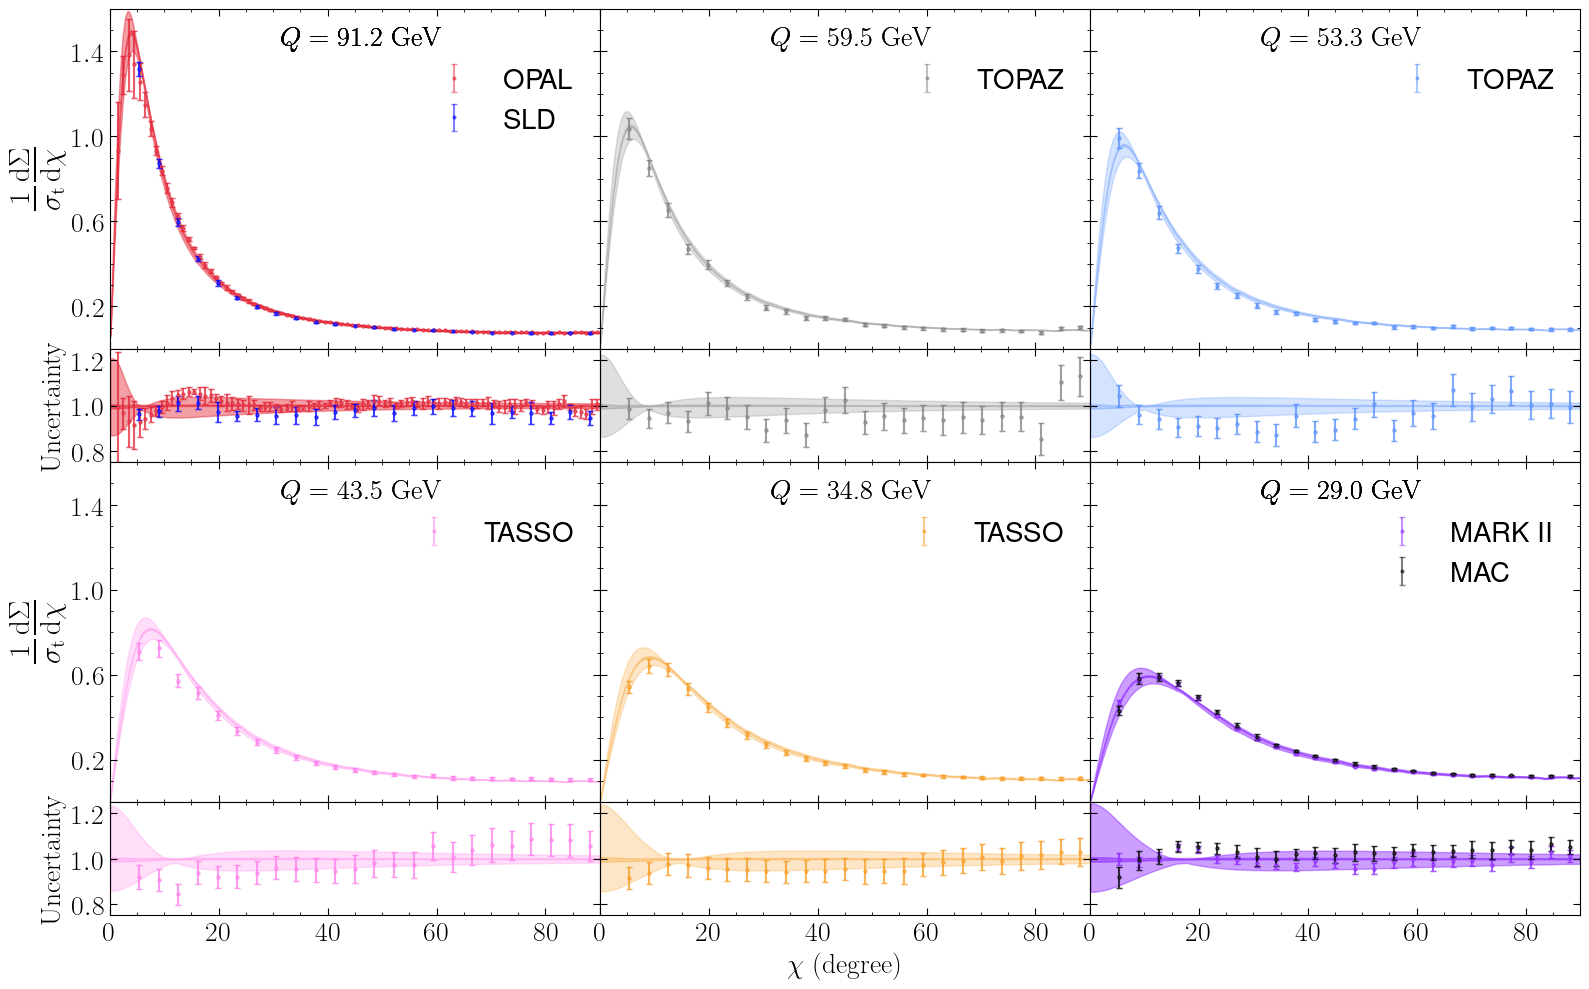

In [42]:
fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex='col', gridspec_kw={'height_ratios': [3, 1, 3, 1]})
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12 = axes.ravel()

#Settings-----------------------------------------------------------------
sizeOfFont= 20
sizeOfTick = 20
sizeOfCap = 2
sizeOfMark = 2

props = dict(boxstyle='round', facecolor='white', alpha=0)

#color = ["blue","green","blue","green","blue","green","blue"]
#color = ["red","orange","gray","teal","blue","purple","black"]

blue=(87/255,144/255,252/255)
orange=(248/255,156/255,32/255)
red=(228/255,37/255,54/255)
purple1=(150/150,74/150,139/150)
gray=(156/161,156/161,161/161)
purple2=(122/221,33/221,221/221)

color = [red,"blue","gray",blue,purple1,orange,purple2,"black"]
color_bands = [red,"gray",blue,purple1,orange,purple2]

transparency=[0.3,0.25]
point_transparency=0.5

ax_list = [ax1,ax2,ax3,ax7,ax8,ax9]
ax_ratios = [ax4,ax5,ax6,ax10,ax11,ax12]

Q_set = [91.2,59.5,53.3,43.5,34.8,29.0]
names_band=["OPAL_new","SLD","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARK II","MAC"]
#--------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, mfc='w', alpha=point_transparency)
            ax_list[i].errorbar(df_fitted[name]["CHI"], df_fitted[name]["EEC"], df_fitted[name]["ERROR"], fmt='o', color=color[j], capsize=sizeOfCap,markersize=sizeOfMark,label=str(name_set[name]), alpha=point_transparency)
            j=j+1
    i=i+1

j=0
for XLL in accuracy:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                ax_list[i].fill_between(xlist, EEC_upper[XLL][name], EEC_lower[XLL][name], alpha=transparency[j], color=color_bands[i])
                ax_list[i].text(0.35, 0.95, r"\rm $Q = \ $" + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
        i=i+1
    j=j+1

for ax in ax_list:
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1.0, 0.9))
    ax.set_xlim(χ_plot_lower,χ_plot_upper)
    ax.set_xticks([0,20,40,60,80])
    ax.set_ylim(0.0,1.6)
    ax.set_yticks([0.2,0.6,1.0,1.4])

ax2.set_yticklabels([])
ax3.set_yticklabels([])
ax8.set_yticklabels([])
ax9.set_yticklabels([])

ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.5*sizeOfFont)
ax7.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.5*sizeOfFont)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
j=0
for XLL in accuracy:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                ax_ratios[i].fill_between(xlist, EEC_upper[XLL][name]/central[name], EEC_lower[XLL][name]/central[name], alpha=transparency[j], color=color_bands[i])
        i=i+1
    j=j+1

i=0
j=0
for Q in Q_set:
    for name in names_band:
        if Q_list[name]==Q:
            ax_ratios[i].errorbar(df_plot[name]["CHI"], df_plot[name]["EEC"]/central_data[name], df_plot[name]["ERROR"]/central_data[name], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, mfc='w', alpha=point_transparency)
            ax_ratios[i].errorbar(df_fitted[name]["CHI"], df_fitted[name]["EEC"]/central_fitted[name], df_fitted[name]["ERROR"]/central_fitted[name], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, alpha=point_transparency)
            j=j+1
    i=i+1

for ax in ax_ratios:
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.set_xlim(0.0,χ_plot_upper)
    #ax.set_xticks([10,20,30,40,50,60])
    ax.set_ylim(0.75,1.25)
    ax.set_yticks([0.8,1.0,1.2])

ax5.set_yticklabels([])
ax6.set_yticklabels([])
ax11.set_yticklabels([])
ax12.set_yticklabels([])

ax4.set_ylabel(r"\rm $\rm{Uncertainty}$",fontsize=sizeOfFont)
ax10.set_ylabel(r"\rm $\rm{Uncertainty}$",fontsize=sizeOfFont)
ax11.set_xlabel(r"\rm $\chi \ (\rm{degree})$",fontsize=sizeOfFont)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)
plt.show()

fig.savefig('errobands_1.pdf')

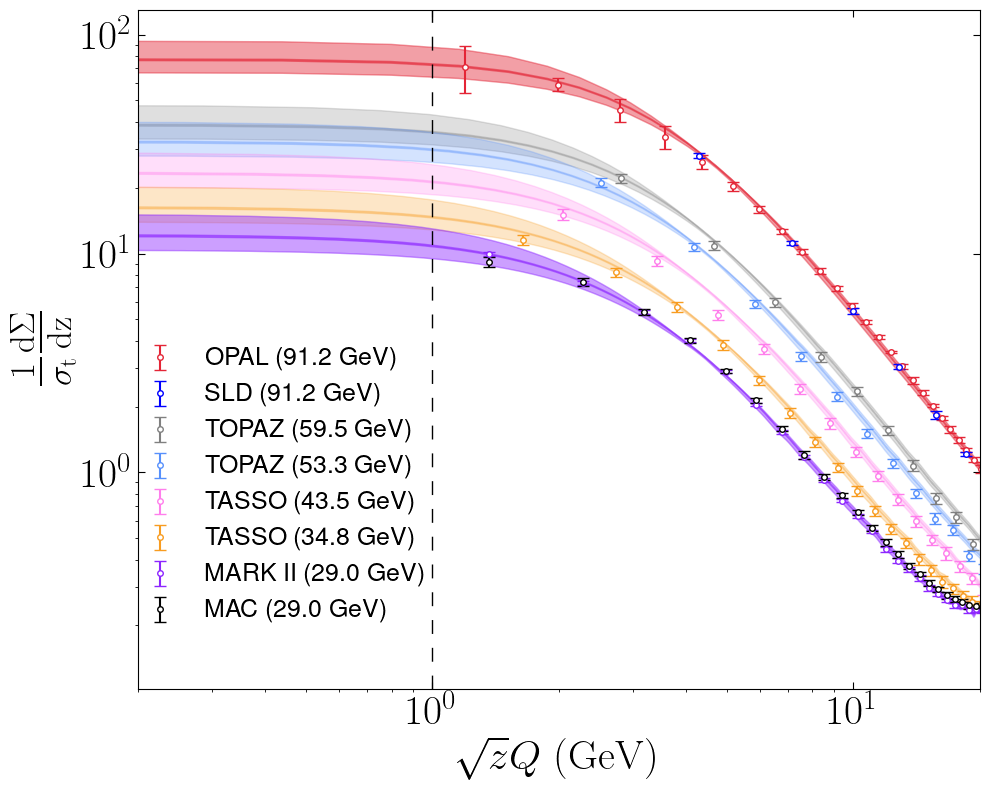

In [61]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Style settings (unchanged)
# ------------------------------------------------------------
sizeOfFont = 20
sizeOfTick = 20
sizeOfCap  = 4
sizeOfMark = 4

props = dict(boxstyle='round', facecolor='white', alpha=0)

Q_set      = [91.2, 59.5, 53.3, 43.5, 34.8, 29.0]
names_band = ["OPAL_new", "SLD", "TOPAZ_595", "TOPAZ_533",
              "TASSO_435", "TASSO_348", "MARK II", "MAC"]

# ------------------------------------------------------------
# Single-panel plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

j = 0                      # colour index
for name in dataset_names:

            # --- build label with energy --------------------
            lab = f"{name_set[name]} ({Q_list[name]} GeV)"
            # ------------------------------------------------

            # experimental points

            sinchi = np.sin(np.pi/180*df_truncated[name]["CHI"])
            sinchid2 = np.sin(np.pi/360*df_truncated[name]["CHI"])

            ax.errorbar(sinchid2*Q_list[name], 
                        2/sinchi*df_truncated[name]["EEC"], 
                        2/sinchi*df_truncated[name]["ERROR"],
                        fmt='o', color=color[j], capsize=sizeOfCap,
                        markersize=sizeOfMark, mfc='w', label=lab)

            j += 1

# ------------------------------------------------------------
# Uncertainty bands (unchanged)
# ------------------------------------------------------------
for k, XLL in enumerate(accuracy):
    for i, Q in enumerate(Q_set):
        for name in names_band:
            if Q_list[name] == Q:

                sinchi = np.sin(np.pi/180*xlist)
                sinchid2 = np.sin(np.pi/360*xlist)

                ax.fill_between(sinchid2*Q, 
                                2/sinchi*EEC_upper[XLL][name],
                                2/sinchi*EEC_lower[XLL][name],
                                alpha=transparency[k],
                                color=color_bands[i])

# ------------------------------------------------------------
# Axis cosmetics (unchanged)
# ------------------------------------------------------------
ax.set_xlabel(r"$\sqrt{z} Q \ (\rm{GeV})$", fontsize=1.5*sizeOfFont)
ax.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} z}$",fontsize=1.8*sizeOfFont)

ax.set_xlim(0.2, 20)
#ax.set_xticks([10, 30, 50, 70, 90])

ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_ylim(0.1, 1.6)
#ax.set_yticks([0.2, 0.6, 1.0, 1.4])

ax.minorticks_on()
ax.tick_params(axis="both", direction="in", length=5, labelsize=1.5*sizeOfTick,
               top=True, right=True)
#ax.tick_params(axis="both", which="minor", direction="in",
#               length=2.5, top=True, right=True)

# Move axes left to make room for legend, then draw legend
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width*0.75, box.height])
ax.legend(frameon=False, fontsize=0.9*sizeOfTick, loc='center left',
          bbox_to_anchor=(-0.03, 0.3))

ax.axvline(1, ls='--', lw=1.0, color="black", dashes=(10, 10))

plt.tight_layout()
plt.show()
fig.savefig("plateu.pdf")

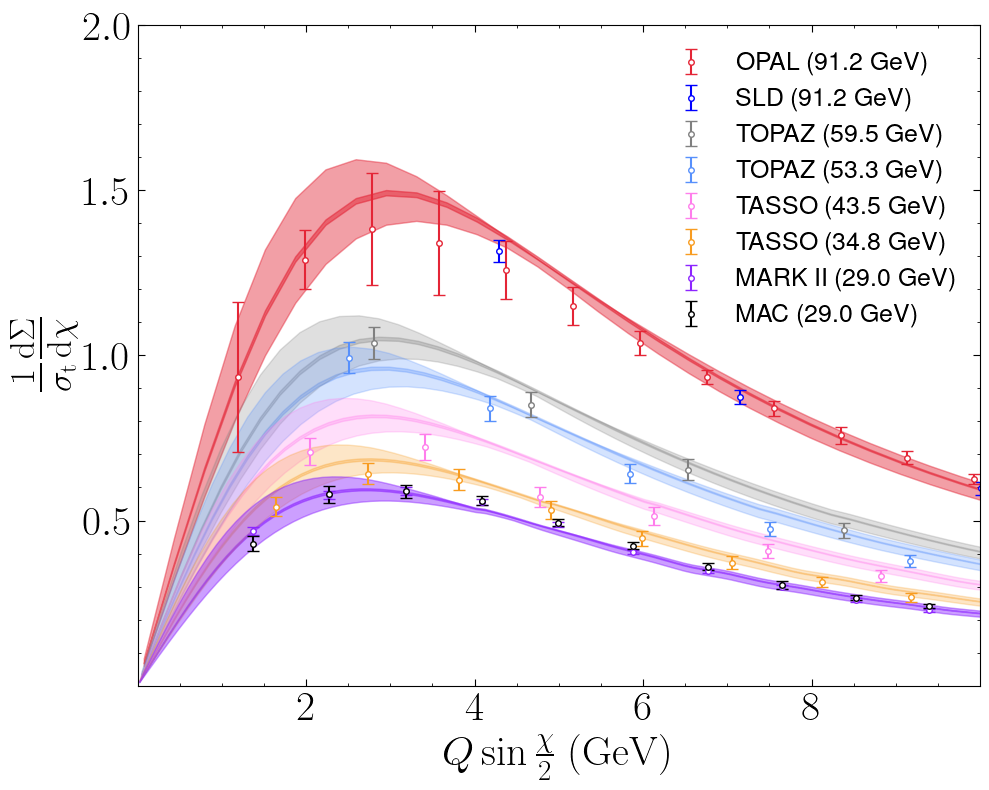

In [45]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Style settings (unchanged)
# ------------------------------------------------------------
sizeOfFont = 20
sizeOfTick = 20
sizeOfCap  = 4
sizeOfMark = 4

props = dict(boxstyle='round', facecolor='white', alpha=0)

blue     = (87/255, 144/255, 252/255)
orange   = (248/255, 156/255,  32/255)
red      = (228/255,  37/255,  54/255)
purple1  = (150/255,  74/255, 139/255)
gray     = (156/255, 161/255, 161/255)
purple2  = (122/255,  33/255, 221/255)

Q_set      = [91.2, 59.5, 53.3, 43.5, 34.8, 29.0]
names_band = ["OPAL_new", "SLD", "TOPAZ_595", "TOPAZ_533",
              "TASSO_435", "TASSO_348", "MARK II", "MAC"]

# ------------------------------------------------------------
# Single-panel plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

j = 0                      # colour index
for name in dataset_names:

            # --- build label with energy --------------------
            lab = f"{name_set[name]} ({Q_list[name]} GeV)"
            # ------------------------------------------------

            # experimental points

            sinchi = np.sin(np.pi/180*df_truncated[name]["CHI"])
            sinchid2 = np.sin(np.pi/360*df_truncated[name]["CHI"])

            ax.errorbar(sinchid2*Q_list[name], 
                        df_truncated[name]["EEC"], 
                        df_truncated[name]["ERROR"],
                        fmt='o', color=color[j], capsize=sizeOfCap,
                        markersize=sizeOfMark, mfc='w', label=lab)

            j += 1

# ------------------------------------------------------------
# Uncertainty bands (unchanged)
# ------------------------------------------------------------
for k, XLL in enumerate(accuracy):
    for i, Q in enumerate(Q_set):
        for name in names_band:
            if Q_list[name] == Q:

                sinchi = np.sin(np.pi/180*xlist)
                sinchid2 = np.sin(np.pi/360*xlist)

                ax.fill_between(sinchid2*Q, 
                                EEC_upper[XLL][name],
                                EEC_lower[XLL][name],
                                alpha=transparency[k],
                                color=color_bands[i])

# ------------------------------------------------------------
# Axis cosmetics (unchanged)
# ------------------------------------------------------------
ax.set_xlabel(r"$ Q \sin{\frac{\chi}{2}} \ (\rm{GeV})$", fontsize=1.5*sizeOfFont)
ax.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.8*sizeOfFont)

ax.set_xlim(0.0, 10)
ax.set_ylim(0.0, 2)

ax.set_xticks([2,4,6,8])
ax.set_yticks([0.5,1,1.5,2])

#ax.set_xscale('log')
#ax.set_yscale('log')
#ax.set_ylim(0.1, 1.6)
#ax.set_yticks([0.2, 0.6, 1.0, 1.4])

ax.minorticks_on()
ax.tick_params(axis="both", direction="in", length=5, labelsize=1.5*sizeOfTick,
               top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in",
               length=2.5, top=True, right=True)

# Move axes left to make room for legend, then draw legend
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width*0.75, box.height])
ax.legend(frameon=False, fontsize=0.9*sizeOfTick, loc='center left',
          bbox_to_anchor=(0.6, 0.75))
 
plt.tight_layout()
plt.show()
fig.savefig("peak.pdf")

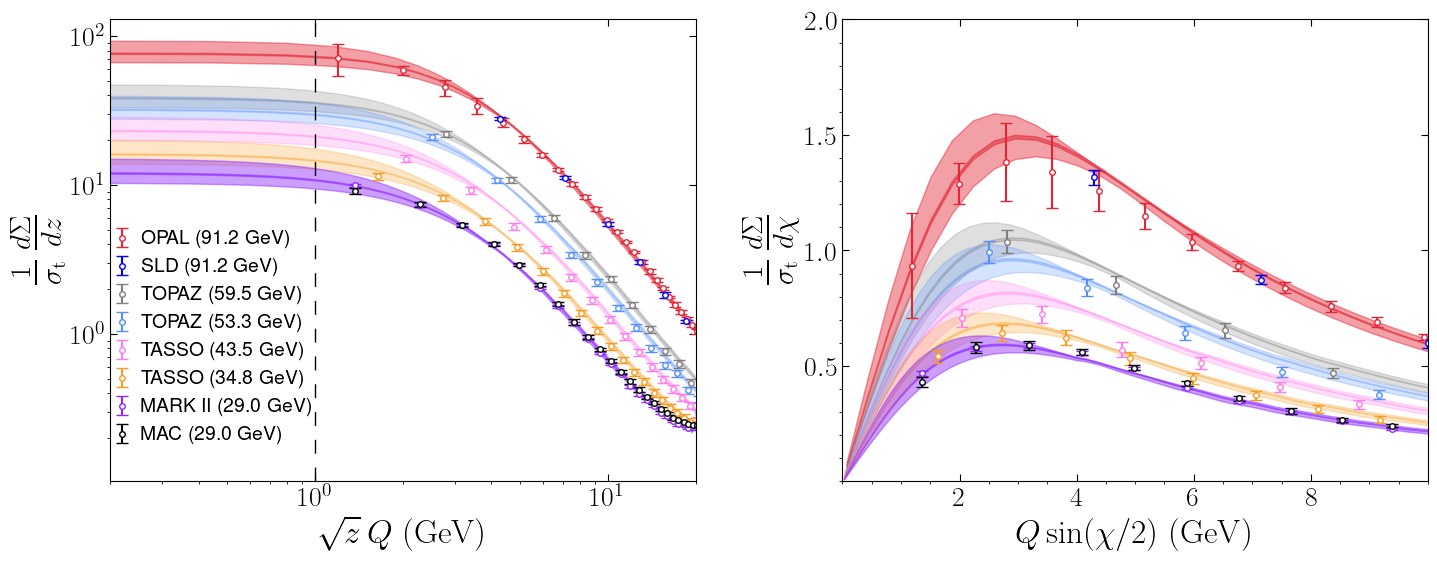

In [103]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'wspace': 0.25})

def plot_zQ(ax):
    j = 0
    for name in dataset_names:
        lab = f"{name_set[name]} ({Q_list[name]} GeV)"
        sinchi   = np.sin(np.pi/180*df_truncated[name]["CHI"])
        sinchid2 = np.sin(np.pi/360*df_truncated[name]["CHI"])
        ax.errorbar(sinchid2*Q_list[name],
                    2/sinchi*df_truncated[name]["EEC"],
                    2/sinchi*df_truncated[name]["ERROR"],
                    fmt='o', color=color[j], capsize=sizeOfCap,
                    markersize=sizeOfMark, mfc='w', label=lab)
        j += 1

    for k, XLL in enumerate(accuracy):
        for i, Q in enumerate(Q_set):
            for name in names_band:
                if Q_list[name] == Q:
                    sinchi   = np.sin(np.pi/180*xlist)
                    sinchid2 = np.sin(np.pi/360*xlist)
                    ax.fill_between(sinchid2*Q,
                                    2/sinchi*EEC_upper[XLL][name],
                                    2/sinchi*EEC_lower[XLL][name],
                                    alpha=transparency[k],
                                    color=color_bands[i])

    ax.set_xlabel(r"$\sqrt{z}\,Q\;(\mathrm{GeV})$", fontsize=1.2*sizeOfFont)
    ax.set_ylabel(r"$\frac{1}{\sigma_{\mathrm{t}}}\,\frac{d\Sigma}{dz}$", fontsize=1.5*sizeOfFont)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.2, 20)
    ax.minorticks_on()
    ax.tick_params(axis="both", direction="in", length=5, labelsize=sizeOfTick,
                   top=True, right=True)
    ax.axvline(1, ls='--', lw=1.0, color="black", dashes=(10, 10))
    # legend later (shared)

def plot_chi(ax):
    j = 0
    for name in dataset_names:
        lab = f"{name_set[name]} ({Q_list[name]} GeV)"
        sinchi   = np.sin(np.pi/180*df_truncated[name]["CHI"])
        sinchid2 = np.sin(np.pi/360*df_truncated[name]["CHI"])
        ax.errorbar(sinchid2*Q_list[name],
                    df_truncated[name]["EEC"],
                    df_truncated[name]["ERROR"],
                    fmt='o', color=color[j], capsize=sizeOfCap,
                    markersize=sizeOfMark, mfc='w', label=lab)
        j += 1

    for k, XLL in enumerate(accuracy):
        for i, Q in enumerate(Q_set):
            for name in names_band:
                if Q_list[name] == Q:
                    sinchi   = np.sin(np.pi/180*xlist)
                    sinchid2 = np.sin(np.pi/360*xlist)
                    ax.fill_between(sinchid2*Q,
                                    EEC_upper[XLL][name],
                                    EEC_lower[XLL][name],
                                    alpha=transparency[k],
                                    color=color_bands[i])

    ax.set_xlabel(r"$Q\sin(\chi / 2)\;(\mathrm{GeV})$", fontsize=1.2*sizeOfFont)
    ax.set_ylabel(r"$\frac{1}{\sigma_{\mathrm{t}}}\,\frac{d\Sigma}{d\chi}$", fontsize=1.5*sizeOfFont)
    ax.set_xlim(0.0, 10); ax.set_ylim(0.0, 2)
    ax.set_xticks([2,4,6,8]); ax.set_yticks([0.5,1,1.5,2])
    ax.minorticks_on()
    ax.tick_params(axis="both", direction="in", length=5, labelsize=sizeOfTick,
                   top=True, right=True)

# draw both
plot_zQ(ax1)
plot_chi(ax2)

# common legend (grab handles from first axis)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=1, fontsize=0.7*sizeOfTick,
           loc='center left', bbox_to_anchor=(0.11, 0.35), columnspacing=1.0, handletextpad=0.0)

#plt.tight_layout(rect=[0.3, 0, 1, 1])  # leave space for legend
fig.savefig("combined.pdf")
plt.show()